In [90]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import math
from PIL import Image
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
fs = 9
plt.rcParams.update({'font.size': fs})

In [91]:
datapath = '../data/Wang/'
targets = ['log_p_sat', 'log_kwg', 'log_kwiomg']
files = [target + '.txt' for target in targets]
arrs = []
for file in files:
    arrs.append(pd.read_csv(datapath + file, header=None).values.flatten())
Wang_len = len(arrs[0])

In [92]:
datapath = '../data/GeckoQ/'
gecko_data = pd.read_csv(datapath + 'log_p_sat.txt', header=None).values.flatten()
print(len(gecko_data[gecko_data<-14]))
gecko_data = gecko_data[gecko_data>-14]
arrs.append(gecko_data)

49


In [93]:
datapath = '../data/Ferraz-Caetano/'
fc_data = pd.read_csv(datapath + 'dvap.txt', header=None).values.flatten()
print(len(fc_data[fc_data > 170]))
fc_data = fc_data[fc_data < 170]
print(len(fc_data[fc_data < 20]))
fc_data = fc_data[fc_data > 20]
arrs.append(fc_data)
print(len(fc_data[fc_data > 100 ]))
print(len(fc_data[fc_data > 120 ]))
print(len(fc_data[fc_data > 140 ]))
print(fc_data.max())

29
3
162
63
20
167.6


In [94]:
datapath = '../data/Li/'
li_data = pd.read_csv(datapath + 'tg.txt', header=None).values.flatten()
print(len(li_data[li_data > 440]))
li_data = li_data[li_data < 440]
print(len(li_data[li_data < 70]))
li_data = li_data[li_data > 70]
arrs.append(li_data)

3
6


In [95]:
def round_up_to_nearest_x(n, x):
    return ((n + x-1) // x) * x

[0.   0.04 0.08 0.12]
[0.   0.04 0.08 0.12]


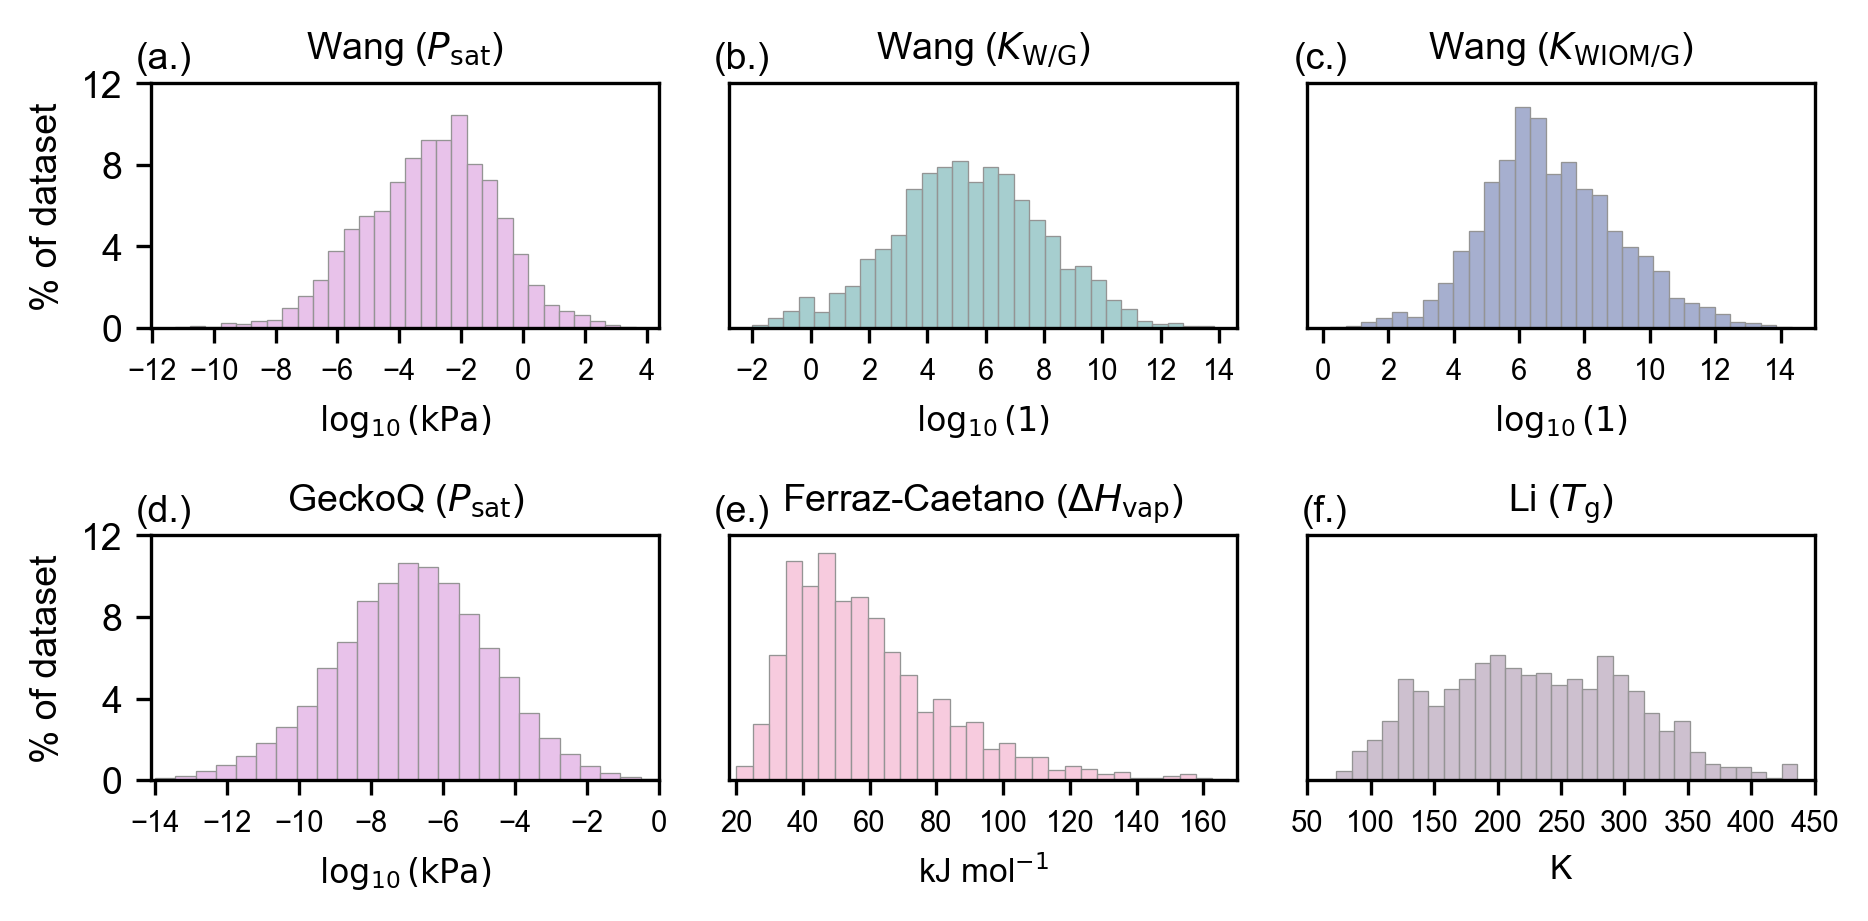

In [96]:
target_labels = [
    r'$P_{\text{sat}}$',
    r'$K_{\text{W}/\text{G}}$',
    r'$K_{\text{WIOM}/\text{G}}$',
    r'$P_{\text{sat}}$',
    r'$\Delta H_\text{vap}$',
    r'$T_\text{g}$'
]
units = [
    r'$\log_{10} (\text{kPa})$',
    r'$\log_{10} (1)$',
    r'$\log_{10} (1)$',
    r'$\log_{10} (\text{kPa})$',
    r'kJ mol$^{-1}$',
    r'K'
]

subplot_labels=['a.', 'b.', 'c.', 'd.', 'e.', 'f.']
datasetnames= ['Wang', 'Wang', 'Wang', 'GeckoQ', 'Ferraz-Caetano', 'Li']

bins_ = [30]
colors = ['#53555e',  # dark gray / charcoal: MACCS
          '#f5bad3',   # soft pink / baby pink: ATMO 
          '#e1aee4',  # pastel pink-purple / light orchid: ATMOMACCS v1
          '#bdabbf',  # muted lavender / dusty lilac: ATMOMACCS v2
          '#949494',  # light gray '#89bebf': TopFP
          '#b9e4e4',  # light aqua / pale cyan: : ATMOMACCS v3
          '#89bebf',  # muted teal / soft cyan: ATMOMACCS v4
          '#8995BF'  # desaturated periwinkle / dusty indigo: : ATMOMACCS v5
         ]

colors = [
    '#e1aee4',  # pastel pink-purple / light orchid: ATMOMACCS v1
    '#89bebf',  # muted teal / soft cyan: ATMOMACCS v4
    '#8995BF',  # desaturated periwinkle / dusty indigo: : ATMOMACCS v5
    '#e1aee4',  # pastel pink-purple / light orchid: ATMOMACCS v1
    '#f5bad3',   # soft pink / baby pink: ATMO 
    '#bdabbf',  # muted lavender / dusty lilac: ATMOMACCS v2
]
size = (0.9* 504, 0.9*252)
for j, num_bins in enumerate(bins_):
    axes = []
    plt.figure(figsize=(size[0]/72, size[1]/72))
    plt.gcf().set_dpi(300)
    for i, (target, data, unit) in enumerate(zip(target_labels, arrs, units)):
        ax = plt.subplot(2, 3, i+1)  # 1 row, 3 columns, subplot i+1
        sns.histplot(data, bins=num_bins, edgecolor='#949494', color=colors[i], stat='probability')  # Plot histogram for the data
        axes.append(ax)
        plt.xlabel(f'{unit}', fontsize=fs-1)  # Set x-axis label
        plt.title(f'{datasetnames[i]} ({target})', fontsize=fs)
        plt.xticks(fontsize=fs)
        ax.text(0.08, 1.17, f'({subplot_labels[i]})', transform=ax.transAxes, 
                fontsize=fs, va='top', ha='right')

        if i == 0:
            plt.ylabel('% of dataset', fontsize=fs)  # Set y-axis label
            plt.xticks(np.linspace(-12, 4, num=9), fontsize=fs-2)
        elif i == 1:
            plt.ylabel(None)
            plt.xticks(np.linspace(-2,14, num=9), fontsize=fs-2)
        elif i == 2:
            plt.ylabel(None)
            plt.xticks(np.linspace(0,14, num=8), fontsize=fs-2)
        elif i == 3:
            plt.ylabel('% of dataset', fontsize=fs)  # Set y-axis label
            plt.xticks(np.linspace(-14, 2, num=9), fontsize=fs-2)
            plt.xlim([-14.1, 0])
        elif i == 4:
            plt.ylabel(None)  # Set y-axis label
            plt.xticks(np.linspace(20, 160, num=8), fontsize=fs-2)
            plt.xlim([18, 170])
        elif i == 5:
            plt.ylabel(None)  # Set y-axis label
            plt.xticks(np.linspace(0, 450, num=10), fontsize=fs-2)
            plt.xlim([50, 450])
    # TODO: change the ylim of each subplot to the same:
    for i, ax_ in enumerate(axes):
        ax_.set_ylim([0, 0.12001])
        if ax_ is axes[0]:  # Only show y-ticks on the first subplot
            ticks = np.linspace(0, 0.12, num=4)
            print(ticks)
            ax_.set_yticks(ticks)
            ax_.set_yticklabels((100 * ticks).astype(int))
        elif ax_ is axes[3]:  # Only show y-ticks on the first subplot
            ticks = np.linspace(0, 0.12, num=4)
            print(ticks)
            ax_.set_yticks(ticks)
            ax_.set_yticklabels((100 * ticks).astype(int))
        else:
            ax_.set_yticks([])  # Remove y-ticks for the other subplots
    plt.tight_layout()
    plt.savefig(f'targets/All_targets_{num_bins}_bins_{size[0]}x{size[1]}.png', dpi=300)
    plt.show()




In [97]:
# List of image paths
images = [f'targets/Wang_targets_{num_bins}_bins_{size[0]}x{size[1]}.png' for num_bins in bins_]

# Load images and convert them to numpy arrays
loaded_images = [np.array(Image.open(img)) for img in images]

# Stack images vertically using numpy.vstack
stacked_image_array = np.vstack(loaded_images)

# Convert the stacked array back to an image
stacked_image = Image.fromarray(stacked_image_array)

# Save the final stacked image
stacked_image.save('targets/stacked_image.png')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\kuuli\\Documents\\pyprojects\\ATMOMACCS_c,e\\notebooks\\targets\\Wang_targets_30_bins_453.6x226.8.png'

In [ ]:
plt.close()
datapath = '../data/GeckoQ/'
targets = ['log_p_sat']
target_labels = [
    r'$P_{\text{sat}}$',
    r'$K_{\text{W}/\text{G}}$',
    r'$K_{\text{WIOM}/\text{G}}$'
]
units = [
    r'$\log_{10} (\text{kPa})$',
    r'$\log_{10} (1)$',
    r'$\log_{10} (1)$'
]
files = [target + '.txt' for target in targets]
arrs = []
for file in files:
    arrs.append(pd.read_csv(datapath + file, header=None).values.flatten())

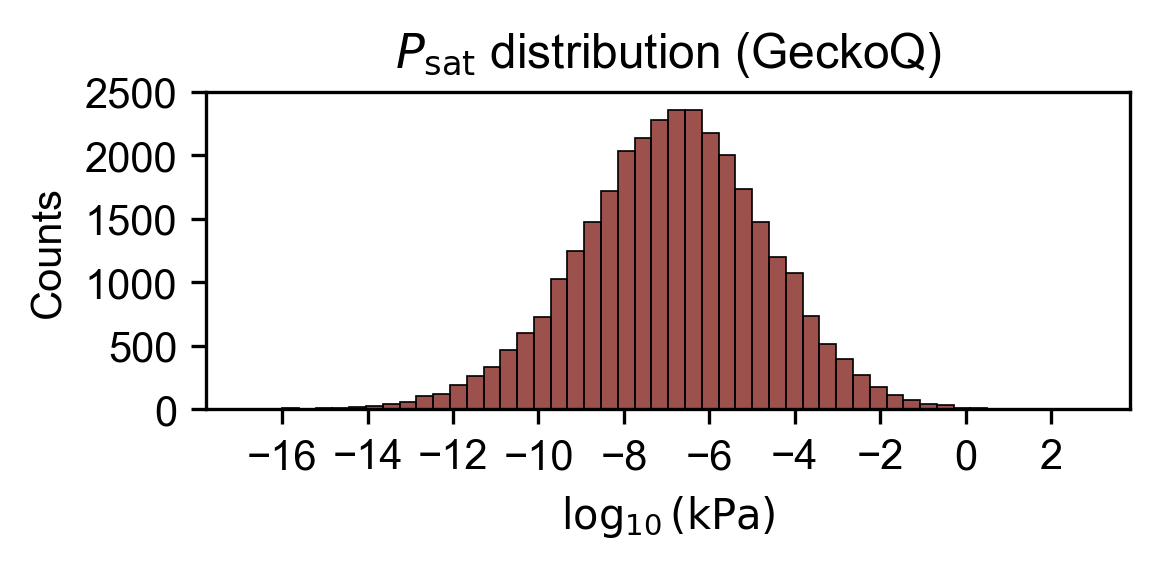

In [ ]:
num_bins = 50
size = (504 * 1.7 / 3, 216 / 1.5)
plt.figure(figsize=((size[0])/72, size[1]/72))
plt.gcf().set_dpi(300)
for i, (target, data, unit) in enumerate(zip(target_labels, arrs, units)):
    sns.histplot(data, bins=num_bins, edgecolor='black', color='#7b1711')  # Plot histogram for the data
    plt.xlabel(f'{unit}', fontsize=fs)  # Set x-axis label
    plt.title(f'{target} distribution (GeckoQ)', fontsize=fs+1.5)
    plt.xticks(fontsize=fs)
    if i == 0:
        plt.ylabel('Counts', fontsize=fs)  # Set y-axis label
        plt.yticks(np.linspace(0, 2500, num=6), fontsize=fs)
        plt.xticks(np.linspace(-16, 2, num=10), fontsize=fs)
    elif i == 1:
        plt.ylabel(None)
        plt.yticks([], [])
        plt.xticks(np.linspace(-2,14, num=9), fontsize=fs)
    elif i == 2:
        plt.ylabel(None)
        plt.yticks([], [])
        plt.xticks(np.linspace(0,14, num=8), fontsize=fs)
    plt.ylim([0,2500])
plt.tight_layout()
plt.savefig(f'targets/GeckoQ_targets_{num_bins}_bins_{round(size[0]/2)}x{size[1]}.png', dpi=300)
plt.show()

In [ ]:
GeckoQ_len = len(arrs[0])
plt.close()

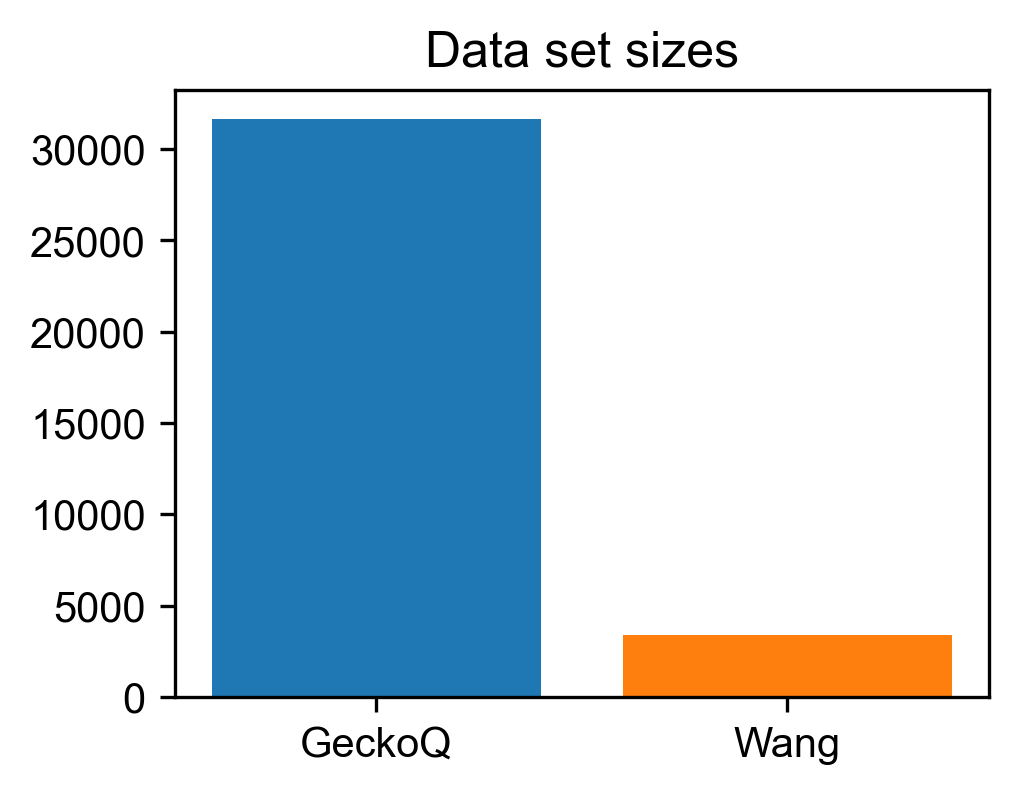

In [ ]:
plt.figure(figsize=(7/2, 5.25/2))
plt.gcf().set_dpi(300)
plt.bar('GeckoQ', GeckoQ_len)
plt.bar('Wang', Wang_len)
plt.title('Data set sizes')
plt.show()